# Дифференциальный анализ экспрессии генов (Bulk RNA-seq)

## PyDESeq2 Pipeline: поиск дифференциально экспрессированных генов (DEGs)

Этот ноутбук демонстрирует полный пайплайн анализа bulk RNA-seq данных с использованием библиотеки **PyDESeq2** — Python-реализации популярного R-пакета DESeq2.

### Биологический контекст

**RNA-секвенирование (RNA-seq)** позволяет измерить уровень экспрессии тысяч генов одновременно. При сравнении двух или более условий (например, здоровые vs больные ткани, контрольные vs обработанные клетки) мы ищем гены, экспрессия которых **статистически значимо различается** — такие гены называются **дифференциально экспрессированными генами (Differentially Expressed Genes, DEGs)**.

**DESeq2** использует модель **отрицательного биномиального распределения** (Negative Binomial) для подсчётов прочтений, что позволяет корректно учитывать как техническую, так и биологическую вариабельность.

## 1. Импорт библиотек и настройка

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from pydeseq2.dds import DeseqDataSet
from pydeseq2.default_inference import DefaultInference
from pydeseq2.ds import DeseqStats
from pydeseq2.utils import load_example_data

# Настройка визуализации
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.figsize"] = (10, 6)
warnings.filterwarnings("ignore")

DATA_DIR = Path("data")

## 2. Загрузка данных

### Формат входных данных

Для анализа требуются два набора данных:

1. **Матрица подсчётов (counts matrix)** — таблица, где:
   - **Строки** = образцы (samples)
   - **Столбцы** = гены (genes)
   - **Значения** = количество прочтений (raw read counts) для каждого гена в каждом образце

2. **Метаданные образцов (metadata)** — таблица, где:
   - **Строки** = образцы (должны совпадать со строками counts matrix)
   - **Столбцы** = ковариаты/факторы (условие эксперимента, пол, возраст и т.д.)

> **Важно:** DESeq2 работает именно с **сырыми подсчётами** (raw counts), а не с нормализованными значениями (TPM, FPKM). Нормализация выполняется внутри алгоритма через size factors.

In [2]:
# Проверяем, есть ли сохранённые данные
if (DATA_DIR / "counts.csv").exists() and (DATA_DIR / "metadata.csv").exists():
    print("Loading saved data from data/ directory...")
    counts_df = pd.read_csv(DATA_DIR / "counts.csv", index_col=0)
    metadata_df = pd.read_csv(DATA_DIR / "metadata.csv", index_col=0)
else:
    print("Loading PyDESeq2 synthetic example data...")
    counts_df = load_example_data(
        modality="raw_counts",
        dataset="synthetic",
        debug=False,
    )
    metadata_df = load_example_data(
        modality="metadata",
        dataset="synthetic",
        debug=False,
    )
    # PyDESeq2 already returns samples x genes format
    counts_df = counts_df

print(f"Counts matrix shape: {counts_df.shape} (samples × genes)")
print(f"Metadata shape: {metadata_df.shape} (samples × covariates)")
print(f"\nMetadata columns: {metadata_df.columns.tolist()}")
print(f"\nCondition values: {metadata_df['condition'].value_counts().to_dict()}")

Loading saved data from data/ directory...
Counts matrix shape: (100, 10) (samples × genes)
Metadata shape: (100, 2) (samples × covariates)

Metadata columns: ['condition', 'group']

Condition values: {'A': 50, 'B': 50}


In [3]:
# Просмотр первых строк данных
print("=== Counts matrix (first 5 samples, first 5 genes) ===")
display(counts_df.iloc[:5, :5])

print("\n=== Metadata (first 5 samples) ===")
display(metadata_df.head())

=== Counts matrix (first 5 samples, first 5 genes) ===


,gene1,gene2,gene3,gene4,gene5
sample1,12,21,4,130,18
sample2,1,44,2,63,11
sample3,4,4,11,180,21
sample4,1,10,2,100,44
sample5,1,11,6,135,16



=== Metadata (first 5 samples) ===


,condition,group
sample1,A,X
sample2,A,Y
sample3,A,X
sample4,A,Y
sample5,A,X


## 3. Предобработка и фильтрация генов

### Зачем фильтровать гены?

В RNA-seq экспериментах многие гены имеют **крайне низкий уровень экспрессии** (0–10 прочтений). Такие гены:

- Вносят преимущественно **технический шум**, а не биологический сигнал
- Увеличивают нагрузку на вычисления
- Усугубляют проблему **множественного тестирования** (чем больше тестов, тем строже коррекция p-значений)

Стандартная практика — отфильтровывать гены с суммарным количеством прочтений ниже порога (обычно **< 10** по всем образцам).

In [4]:
# Фильтрация генов с низкой экспрессией
MIN_TOTAL_COUNTS = 10

genes_to_keep = counts_df.columns[counts_df.sum(axis=0) >= MIN_TOTAL_COUNTS]
counts_filtered = counts_df[genes_to_keep]

n_removed = counts_df.shape[1] - counts_filtered.shape[1]
print(f"Генов до фильтрации: {counts_df.shape[1]}")
print(f"Генов после фильтрации: {counts_filtered.shape[1]}")
print(f"Удалено генов с total counts < {MIN_TOTAL_COUNTS}: {n_removed}")

Генов до фильтрации: 10
Генов после фильтрации: 10
Удалено генов с total counts < 10: 0


In [5]:
# Удаление образцов с пропущенными значениями в метаданных
samples_valid = ~metadata_df["condition"].isna()
counts_filtered = counts_filtered.loc[samples_valid]
metadata_filtered = metadata_df.loc[samples_valid]

print(f"Образцов после фильтрации: {counts_filtered.shape[0]}")
print(f"Удалено образцов с NA в condition: {(~samples_valid).sum()}")

Образцов после фильтрации: 100
Удалено образцов с NA в condition: 0


## 4. Моделирование с DeseqDataSet

### Что такое дисперсия в RNA-seq?

**Дисперсия (variance)** описывает, насколько сильно варьирует экспрессия гена между биологическими репликами.

В RNA-seq данные имеют два источника вариабельности:

1. **Техническая вариабельность** — шум, связанный с подготовкой библиотеки, секвенированием, и т.д. Следует распределению Пуассона (дисперсия ≈ среднее).

2. **Биологическая вариабельность** — реальные различия между образцами (генетика, среда, стохастичность экспрессии). Приводит к **сверхдисперсионности** (overdispersion): дисперсия > среднего.

**DESeq2** моделирует подсчёты через **отрицательное биномиальное распределение**:

$$Var = \mu + \alpha \mu^2$$

где $\mu$ — среднее, $\alpha$ — параметр дисперсии. Зависимость $\alpha$ от $\mu$ оценивается по всем генам и сглаживается (dispersion trend), что повышает стабильность оценок при малом числе реплик.

In [6]:
# Инициализация DeseqDataSet
inference = DefaultInference(n_cpus=8)

dds = DeseqDataSet(
    counts=counts_filtered,
    metadata=metadata_filtered,
    design="~condition",     # Фактор дизайна: сравниваем по условию
    refit_cooks=True,        # Пересчёт выбросов (Cook's distance)
    inference=inference,
)

# Запуск полного пайплайна DESeq2:
# 1. Оценка size factors (нормализация по глубине секвенирования)
# 2. Оценка дисперсий (dispersion estimation)
# 3. Подгонка модели (fitting NB GLM)
# 4. Оценка логарифмических изменений кратности (LFC)
dds.deseq2()

print("DeseqDataSet: подгонка модели завершена!")

Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.00 seconds.



DeseqDataSet: подгонка модели завершена!


Fitting dispersions...
... done in 0.01 seconds.

Fitting dispersion trend curve...
... done in 0.01 seconds.

Fitting MAP dispersions...
... done in 0.02 seconds.

Fitting LFCs...
... done in 0.01 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.



### Log2 Fold Change (LFC)

**Fold Change (FC)** — отношение экспрессии гена в двух условиях. Например, FC = 2 означает 2-кратное увеличение.

**Log2 Fold Change (LFC)** — логарифм FC по основанию 2:

- **LFC = 1** → 2-кратное увеличение (upregulation)
- **LFC = -1** → 2-кратное уменьшение (downregulation)  
- **LFC = 0** → нет изменения

Логарифмирование делает шкалу **симметричной** (up/down регуляция равноправны) и упрощает статистическое моделирование.

## 5. Статистический тест (Wald test)

### Тест Вальда

После подгонки модели DESeq2 выполняет **тест Вальда** для каждого гена:

$$W = \frac{\hat{\beta}}{SE(\hat{\beta})}$$

где $\hat{\beta}$ — оценка LFC, $SE$ — стандартная ошибка. Статистика $W$ распределена приблизительно как $N(0, 1)$.

### Множественное тестирование

Мы тестируем ~10,000+ генов одновременно. При пороге p < 0.05 ожидаем ~500 ложноположительных результатов случайно!

**Коррекция Бенджамини-Хохберга (BH)** контролирует **False Discovery Rate (FDR)** — долю ложных открытий среди всех значимых. Скорректированное p-значение называется **padj** или **q-value**.

- **padj < 0.05** означает: среди генов, прошедших этот порог, ожидаемая доля ложноположительных ≤ 5%

In [7]:
# Инициализация DeseqStats
# contrast = [фактор, numerator, reference]
# Сравниваем condition B vs A
contrast = ["condition", "B", "A"]

ds = DeseqStats(
    dds,
    contrast=contrast,
    inference=inference,
)

# Запуск Wald test: вычисление p-значений и коррекция BH
ds.summary()

print(f"\nВсего генов в анализе: {len(ds.results_df)}")
print(f"Значимых генов (padj < 0.05): {(ds.results_df['padj'] < 0.05).sum()}")

Log2 fold change & Wald test p-value: condition B vs A
          baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
gene1     8.541317        0.632812  0.289101  2.188898  0.028604  0.064150
gene2    21.281239        0.538552  0.149963  3.591236  0.000329  0.001646
gene3     5.010123       -0.632830  0.295236 -2.143476  0.032075  0.064150
gene4   100.517961       -0.412102  0.118629 -3.473868  0.000513  0.001710
gene5    27.142450        0.582065  0.154706  3.762409  0.000168  0.001646
gene6     5.413043        0.001457  0.310311  0.004696  0.996253  0.996253
gene7    28.294023        0.134338  0.149945  0.895917  0.370297  0.411441
gene8    40.358344       -0.270656  0.136401 -1.984261  0.047227  0.078711
gene9    37.166183       -0.212715  0.133243 -1.596437  0.110391  0.143147
gene10   11.589325        0.386011  0.244588  1.578207  0.114518  0.143147

Всего генов в анализе: 10
Значимых генов (padj < 0.05): 3


Running Wald tests...
... done in 0.01 seconds.



In [8]:
# Топ-20 генов по скорректированному p-значению
top_genes = ds.results_df.nsmallest(20, "padj")
print("=== Top 20 Differentially Expressed Genes (by padj) ===")
display(top_genes[["baseMean", "log2FoldChange", "lfcSE", "stat", "pvalue", "padj"]])

=== Top 20 Differentially Expressed Genes (by padj) ===


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
gene2,21.281239,0.538552,0.149963,3.591236,0.000329,0.001646
gene5,27.142450,0.582065,0.154706,3.762409,0.000168,0.001646
gene4,100.517961,-0.412102,0.118629,-3.473868,0.000513,0.001710
gene1,8.541317,0.632812,0.289101,2.188898,0.028604,0.064150
gene3,5.010123,-0.632830,0.295236,-2.143476,0.032075,0.064150
gene8,40.358344,-0.270656,0.136401,-1.984261,0.047227,0.078711
gene9,37.166183,-0.212715,0.133243,-1.596437,0.110391,0.143147
gene10,11.589325,0.386011,0.244588,1.578207,0.114518,0.143147
gene7,28.294023,0.134338,0.149945,0.895917,0.370297,0.411441
gene6,5.413043,0.001457,0.310311,0.004696,0.996253,0.996253


## 6. Сжатие LFC (LFC Shrinkage)

### Зачем сжимать LFC?

Для генов с **низкой экспрессией** или **малым числом реплик** оценки LFC могут быть крайне зашумлёнными и экстремальными. Это приводит к:

- Некорректному ранжированию генов
- Артефактам на volcano plot и MA-plot
- Замыленным оценкам эффекта

### Метод apeGLM

**apeGLM** (adaptive prior estimation via GLM) использует **апостериорное сжатие** (MAP shrinkage): гены с малым количеством информации (высокая SE) стягиваются ближе к нулю, а хорошо измеренные гены сохраняют свои оценки.

Результат — более надёжные оценки LFC, особенно важные для визуализации и последующего анализа (GSEA, pathways).

In [9]:
# LFC shrinkage: коэффициент 'condition[T.B]' означает сравнение B vs A
ds.lfc_shrink(coeff="condition[T.B]")

print(f"LFC shrinkage applied. Shrunk LFCs: {ds.shrunk_LFCs}")
print("\n=== Top 20 DEGs after LFC shrinkage ===")
display(ds.results_df.nsmallest(20, "padj"))

Shrunk log2 fold change & Wald test p-value: condition[T.B]
          baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
gene1     8.541317        0.408148  0.294271  2.188898  0.028604  0.064150
gene2    21.281239        0.480228  0.151198  3.591236  0.000329  0.001646
gene3     5.010123       -0.396066  0.300796 -2.143476  0.032075  0.064150
gene4   100.517961       -0.374346  0.118704 -3.473868  0.000513  0.001710
gene5    27.142450        0.521534  0.156204  3.762409  0.000168  0.001646
gene6     5.413043        0.000715  0.239203  0.004696  0.996253  0.996253
gene7    28.294023        0.103473  0.141497  0.895917  0.370297  0.411441
gene8    40.358344       -0.226414  0.133479 -1.984261  0.047227  0.078711
gene9    37.166183       -0.175964  0.129142 -1.596437  0.110391  0.143147
gene10   11.589325        0.239935  0.231986  1.578207  0.114518  0.143147
LFC shrinkage applied. Shrunk LFCs: True

=== Top 20 DEGs after LFC shrinkage ===


Fitting MAP LFCs...
... done in 0.01 seconds.



,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
gene2,21.281239,0.480228,0.151198,3.591236,0.000329,0.001646
gene5,27.142450,0.521534,0.156204,3.762409,0.000168,0.001646
gene4,100.517961,-0.374346,0.118704,-3.473868,0.000513,0.001710
gene1,8.541317,0.408148,0.294271,2.188898,0.028604,0.064150
gene3,5.010123,-0.396066,0.300796,-2.143476,0.032075,0.064150
gene8,40.358344,-0.226414,0.133479,-1.984261,0.047227,0.078711
gene9,37.166183,-0.175964,0.129142,-1.596437,0.110391,0.143147
gene10,11.589325,0.239935,0.231986,1.578207,0.114518,0.143147
gene7,28.294023,0.103473,0.141497,0.895917,0.370297,0.411441
gene6,5.413043,0.000715,0.239203,0.004696,0.996253,0.996253


## 7. Визуализация результатов

### 7.1 MA-plot

MA-plot показывает зависимость между **средней экспрессией (M)** и **логарифмом отношения (A)**:

- **X-axis (mean of normalized counts)**: средняя нормализованная экспрессия гена
- **Y-axis (log2FoldChange)**: изменение экспрессии между условиями

Гены с высокой экспрессией (справа) имеют более точные оценки LFC. Гены с низкой экспрессией (слева) показывают больший разброс — именно для них LFC shrinkage наиболее важен.

Значимые гены (padj < 0.05) выделены цветом.

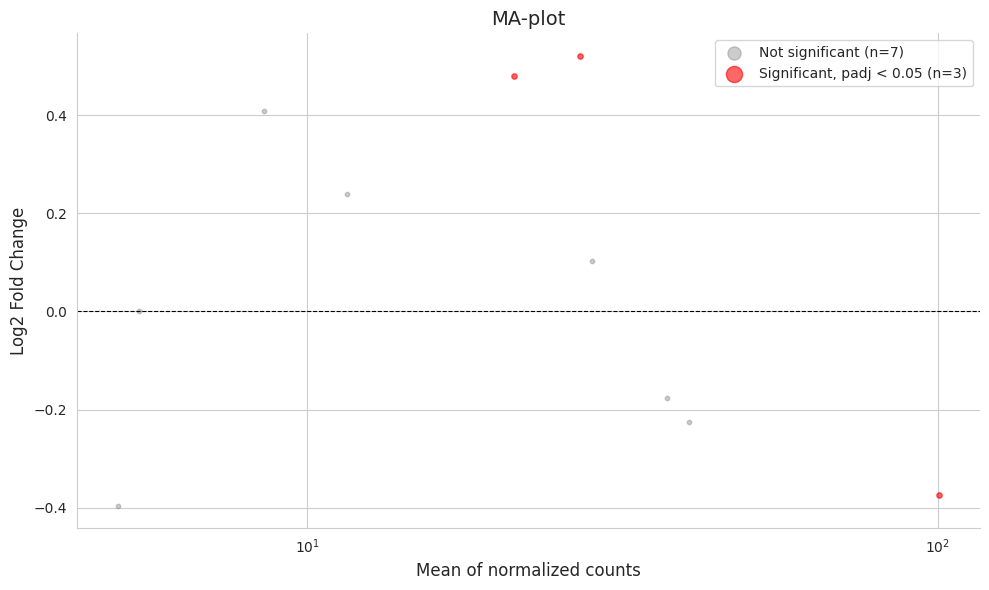

In [10]:
def plot_ma_plot(results_df, ax=None, padj_threshold=0.05):
    """MA-plot: mean expression vs log2FoldChange."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))

    is_sig = results_df["padj"] < padj_threshold
    is_not_sig = ~is_sig & results_df["padj"].notna()

    ax.scatter(
        results_df.loc[is_not_sig, "baseMean"],
        results_df.loc[is_not_sig, "log2FoldChange"],
        alpha=0.4,
        s=10,
        color="gray",
        label=f"Not significant (n={is_not_sig.sum()})",
    )
    ax.scatter(
        results_df.loc[is_sig, "baseMean"],
        results_df.loc[is_sig, "log2FoldChange"],
        alpha=0.6,
        s=15,
        color="red",
        label=f"Significant, padj < {padj_threshold} (n={is_sig.sum()})",
    )

    ax.axhline(y=0, color="black", linestyle="--", linewidth=0.8)
    ax.set_xscale("log")
    ax.set_xlabel("Mean of normalized counts", fontsize=12)
    ax.set_ylabel("Log2 Fold Change", fontsize=12)
    ax.set_title("MA-plot", fontsize=14)
    ax.legend(markerscale=3, fontsize=10)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    return ax


fig, ax = plt.subplots(figsize=(10, 6))
plot_ma_plot(ds.results_df, ax=ax)
plt.tight_layout()
plt.savefig("figures/ma_plot.png", dpi=150, bbox_inches="tight")
plt.show()

### 7.2 Volcano plot

Volcano plot объединяет **статистическую значимость** и **величину эффекта**:

- **X-axis (log2FoldChange)**: величина и направление изменения экспрессии
- **Y-axis (-log10(padj))**: статистическая значимость (чем выше, тем значимее)

**Критерии значимых генов:**
- `padj < 0.05` (статистическая значимость)
- `|LFC| > 1` (биологическая значимость: ≥ 2-кратное изменение)

Гены в верхних углах — наиболее интересные кандидаты для дальнейшего изучения.

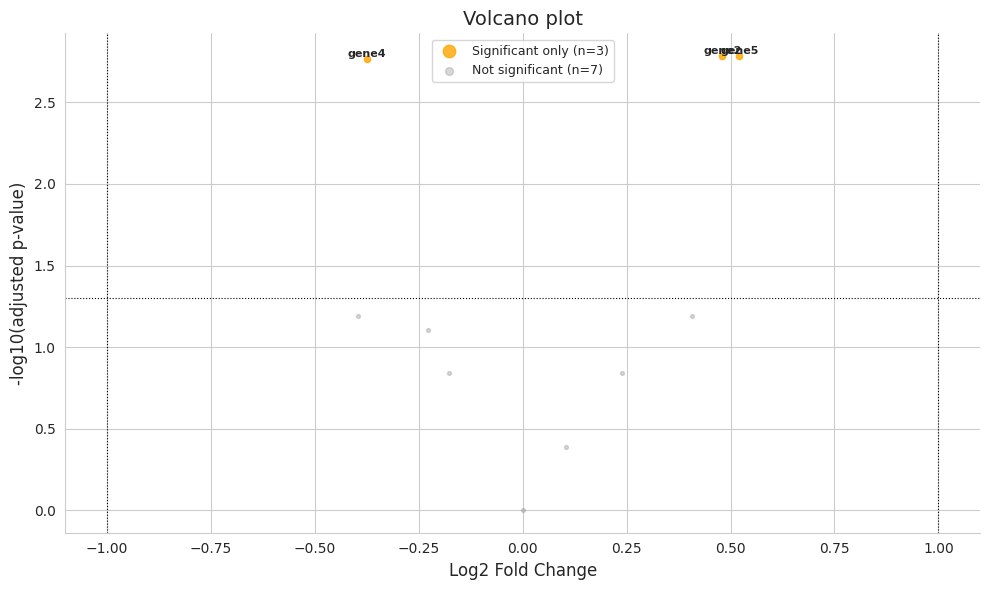

In [11]:
def plot_volcano(
    results_df,
    ax=None,
    padj_threshold=0.05,
    lfc_threshold=1.0,
    top_n_labels=10,
):
    """Volcano plot: -log10(padj) vs log2FoldChange."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))

    df = results_df.copy()
    df["-log10(padj)"] = -np.log10(df["padj"].replace(0, 1e-300))

    # Категоризация генов
    conditions = [
        (df["padj"] < padj_threshold) & (df["log2FoldChange"].abs() > lfc_threshold) & (df["log2FoldChange"] > 0),
        (df["padj"] < padj_threshold) & (df["log2FoldChange"].abs() > lfc_threshold) & (df["log2FoldChange"] < 0),
        (df["padj"] < padj_threshold) & (df["log2FoldChange"].abs() <= lfc_threshold),
        df["padj"] >= padj_threshold,
    ]
    choices = ["Upregulated", "Downregulated", "Significant only", "Not significant"]
    colors_map = {"Upregulated": "red", "Downregulated": "blue", "Significant only": "orange", "Not significant": "gray"}
    df["category"] = np.select(conditions, choices, default="Not significant")

    for category, color in colors_map.items():
        mask = df["category"] == category
        if mask.sum() == 0:
            continue
        alpha = 0.8 if category != "Not significant" else 0.3
        size = 20 if category != "Not significant" else 8
        ax.scatter(
            df.loc[mask, "log2FoldChange"],
            df.loc[mask, "-log10(padj)"],
            alpha=alpha,
            s=size,
            color=color,
            label=f"{category} (n={mask.sum()})",
        )

    # Пороговые линии
    ax.axvline(x=lfc_threshold, color="black", linestyle=":", linewidth=0.8)
    ax.axvline(x=-lfc_threshold, color="black", linestyle=":", linewidth=0.8)
    ax.axhline(y=-np.log10(padj_threshold), color="black", linestyle=":", linewidth=0.8)

    # Подписи топ-n генов
    sig_genes = df[df["padj"] < padj_threshold].nlargest(top_n_labels, "-log10(padj)")
    for gene_name, row in sig_genes.iterrows():
        ax.annotate(
            gene_name,
            (row["log2FoldChange"], row["-log10(padj)"]),
            fontsize=8,
            ha="center",
            va="bottom",
            fontweight="bold",
        )

    ax.set_xlabel("Log2 Fold Change", fontsize=12)
    ax.set_ylabel("-log10(adjusted p-value)", fontsize=12)
    ax.set_title("Volcano plot", fontsize=14)
    ax.legend(markerscale=2, fontsize=9)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    return ax


fig, ax = plt.subplots(figsize=(10, 6))
plot_volcano(ds.results_df, ax=ax, padj_threshold=0.05, lfc_threshold=1.0)
plt.tight_layout()
plt.savefig("figures/volcano_plot.png", dpi=150, bbox_inches="tight")
plt.show()

### 7.3 PCA-plot образцов

PCA (Principal Component Analysis) показывает глобальную структуру данных. Образцы с похожим профилем экспрессии должны группироваться вместе. Это помогает:

- Оценить **разделение между условиями**
- Выявить **batch-эффекты** и выбросы
- Проверить качество эксперимента

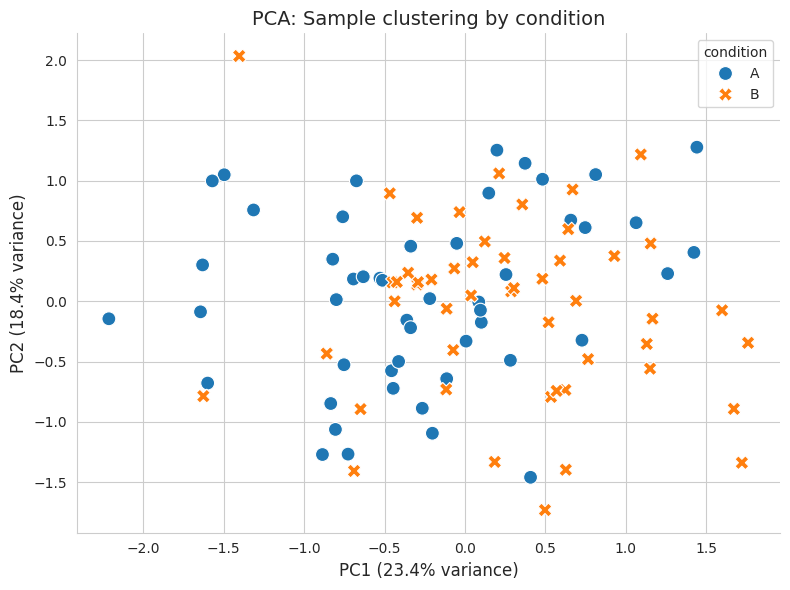

In [12]:
from sklearn.decomposition import PCA  # noqa: E402
from sklearn.preprocessing import StandardScaler  # noqa: E402


def plot_pca_samples(counts_df, metadata_df, ax=None):
    """PCA plot of samples based on normalized counts."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))

    # Нормализация по size factors (из DeseqDataSet)
    size_factors = dds.obs["size_factors"].values
    normalized_counts = counts_df.values / size_factors.reshape(-1, 1)

    # Логарифмическая трансформация
    log_counts = np.log2(normalized_counts + 1)

    # PCA
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(log_counts.T)  # genes x samples
    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(scaled_data.T)  # back to samples

    plot_df = pd.DataFrame({
        "PC1": pca_result[:, 0],
        "PC2": pca_result[:, 1],
        "condition": metadata_df.loc[counts_df.index, "condition"].values,
    })

    sns.scatterplot(
        data=plot_df,
        x="PC1",
        y="PC2",
        hue="condition",
        style="condition",
        s=100,
        ax=ax,
    )

    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)", fontsize=12)
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)", fontsize=12)
    ax.set_title("PCA: Sample clustering by condition", fontsize=14)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    return ax


fig, ax = plt.subplots(figsize=(8, 6))
plot_pca_samples(counts_filtered, metadata_filtered, ax=ax)
plt.tight_layout()
plt.savefig("figures/pca_plot.png", dpi=150, bbox_inches="tight")
plt.show()

### 7.4 Распределение p-значений

Гистограмма p-значений — диагностический инструмент:

- **Пик near 0**: наличие значимых DEGs (хороший сигнал)
- **Равномерное распределение**: большинство генов не дифференциально
- **Пик near 1**: возможные проблемы с моделью или данными

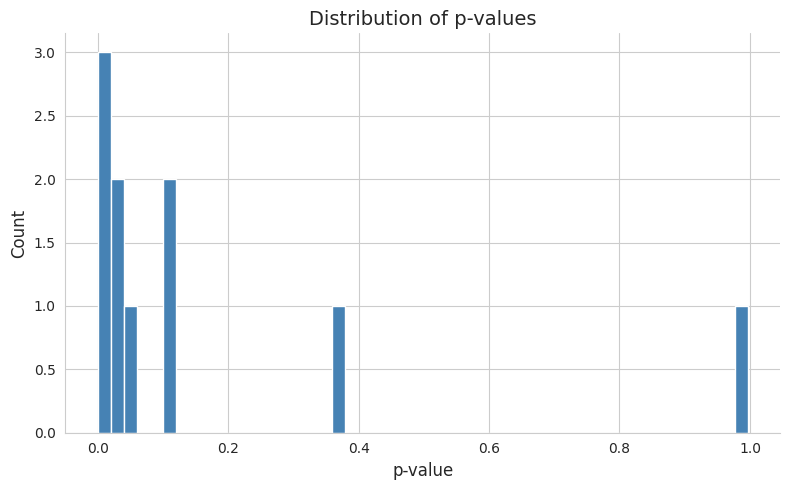

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    ds.results_df["pvalue"].dropna(),
    bins=50,
    color="steelblue",
    edgecolor="white",
)
ax.set_xlabel("p-value", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.set_title("Distribution of p-values", fontsize=14)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("figures/pvalue_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Итоговая таблица DEGs

Полная таблица всех генов с результатами анализа:

In [14]:
# Сводная статистика
results = ds.results_df.copy()
results["significant"] = results["padj"] < 0.05
results["upregulated"] = (results["padj"] < 0.05) & (results["log2FoldChange"] > 0)
results["downregulated"] = (results["padj"] < 0.05) & (results["log2FoldChange"] < 0)

print("=" * 60)
print("SUMMARY")
print("=" * 60)
print(f"Total genes tested:           {len(results):,}")
print(f"Significant (padj < 0.05):    {results['significant'].sum():,} ({results['significant'].mean():.1%})")
print(f"  Upregulated (LFC > 0):      {results['upregulated'].sum():,}")
print(f"  Downregulated (LFC < 0):    {results['downregulated'].sum():,}")
print(f"\nTop 5 most significant genes:")
display(results.nsmallest(5, "padj"))

SUMMARY
Total genes tested:           10
Significant (padj < 0.05):    3 (30.0%)
  Upregulated (LFC > 0):      2
  Downregulated (LFC < 0):    1

Top 5 most significant genes:


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,significant,upregulated,downregulated
gene2,21.281239,0.480228,0.151198,3.591236,0.000329,0.001646,True,True,False
gene5,27.142450,0.521534,0.156204,3.762409,0.000168,0.001646,True,True,False
gene4,100.517961,-0.374346,0.118704,-3.473868,0.000513,0.001710,True,False,True
gene1,8.541317,0.408148,0.294271,2.188898,0.028604,0.064150,False,False,False
gene3,5.010123,-0.396066,0.300796,-2.143476,0.032075,0.064150,False,False,False


In [15]:
# Сохранение результатов
Path("results").mkdir(exist_ok=True)

results.to_csv("results/deseq2_results.csv")
print("Results saved to results/deseq2_results.csv")

# Топ-DEGs для дальнейшего анализа
sig_degs = results[results["padj"] < 0.05].copy()
sig_degs.to_csv("results/significant_degs.csv")
print(f"Significant DEGs saved to results/significant_degs.csv ({len(sig_degs)} genes)")

Results saved to results/deseq2_results.csv
Significant DEGs saved to results/significant_degs.csv (3 genes)


## 9. Заключение

В этом ноутбуке мы выполнили полный пайплайн дифференциального анализа RNA-seq:

1. **Загрузка данных** — матрица подсчётов и метаданные
2. **Фильтрация** — удаление генов с низкой экспрессией
3. **Нормализация и моделирование** — DeseqDataSet (size factors, дисперсии, LFC)
4. **Статистический тест** — Wald test с коррекцией BH (padj)
5. **LFC shrinkage** — apeGLM для более точных оценок
6. **Визуализация** — MA-plot, Volcano plot, PCA, p-value distribution

### Дальнейшие шаги:
- **Functional enrichment analysis** (GO, KEGG pathways) для значимых генов
- **GSEA (Gene Set Enrichment Analysis)** с использованием полного ранжированного списка
- **Сравнение нескольких условий** с контрастами
- **Использование реальных данных** recount3 или GEO